BASIC CHATBOT WITH LANGGRAPH(GRAPH API)

In [ ]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages # add the messages instead of replacing

In [9]:
class State(TypedDict):
  messages: Annotated[list, add_messages]

In [12]:
import os
from dotenv import load_dotenv

load_dotenv()

True

In [13]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model='llama-3.1-8b-instant')

In [15]:
def chatbot(state: State):
  return {'messages':[llm.invoke(state['messages'])]}

In [18]:
graph = StateGraph(State)

graph.add_node('chatbot', chatbot)

graph.add_edge(START, 'chatbot')
graph.add_edge('chatbot',END)

workflow = graph.compile()


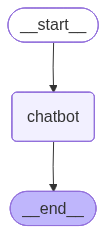

In [19]:
workflow

In [24]:
workflow.invoke({'messages':'HI'})

{'messages': [HumanMessage(content='HI', additional_kwargs={}, response_metadata={}, id='6c5debe4-acd5-4fc8-a1f3-2fb8b5958602'),
  AIMessage(content="It's nice to meet you. Is there something I can help you with, or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 36, 'total_tokens': 60, 'completion_time': 0.026601281, 'completion_tokens_details': None, 'prompt_time': 0.001711324, 'prompt_tokens_details': None, 'queue_time': 0.046336275, 'total_time': 0.028312605}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ed1a9-cd11-7ad0-ba1c-70d434c93e43-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 24, 'total_tokens': 60})]}